# Physical Validation of torch-sim Integrators

We validate torch-sim's MD integrators using the
[physical_validation](https://physical-validation.readthedocs.io/) library
and direct statistical checks.

| Test | What it checks |
|------|---------------|
| **KE Distribution** | Kinetic energy follows Maxwell-Boltzmann $\text{Gamma}(N_f/2,\, k_BT)$ |
| **Ensemble Check (T)** | Energy distributions at two temperatures satisfy $\ln(P_1/P_2) \propto \Delta\beta$ |
| **Ensemble Check (P)** | Volume distributions at two pressures satisfy the Boltzmann weight relationship |
| **NVE Convergence** | Energy-drift RMSD scales as $\mathrm{d}t^2$ (velocity Verlet) |

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import physical_validation
from scipy import stats

from torch_sim.units import MetalUnits


plt.rcParams.update(
    {"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3, "figure.facecolor": "white"}
)

DATA_DIR = Path("tests/physical_validation_data")
k_B_eV = float(MetalUnits.temperature)  # 8.617e-5 eV/K
THRESHOLD = 3.0


def load(name):
    """Load a saved simulation .npz file by integrator/condition name.

    Returns a dict of arrays: temperature, kinetic_energy, potential_energy,
    total_energy, volumes (NPT only), masses, natoms, timestep_ps, etc.
    """
    results = dict(np.load(DATA_DIR / f"{name}.npz", allow_pickle=True))
    # build temperature
    results["temperature"] = (
        2 * results["kinetic_energy"] / (3 * results["natoms"] * k_B_eV)
    )
    return results

In [43]:
def make_unit_data():
    """Create a physical_validation UnitData object for torch-sim's MetalUnits.

    Maps torch-sim's internal unit system (eV, Ang, amu, fs) to the
    physical_validation convention with appropriate conversion factors.
    """
    return physical_validation.data.UnitData(
        kb=k_B_eV,
        energy_str="eV",
        energy_conversion=96.485,
        length_str="Ang",
        length_conversion=1e-1,
        volume_str="Ang^3",
        volume_conversion=1e-3,
        temperature_str="K",
        temperature_conversion=1.0,
        pressure_str="bar",
        pressure_conversion=1,
        time_str="fs",
        time_conversion=1e-3,
    )


def build_sim_data(d, temperature, ensemble="NVT", pressure=None, integrator=None):
    """Build a physical_validation SimulationData from a loaded .npz dict.

    Assembles unit, system, ensemble, and observable data into the format
    required by physical_validation's test functions. Automatically adjusts
    the translational degrees-of-freedom reduction: 0 for Langevin integrators
    (no center-of-mass conservation), 3 otherwise.

    Parameters
    ----------
    d : dict
        Loaded .npz data (from ``load()``).
    temperature : float
        Target temperature in K.
    ensemble : str
        "NVT" or "NPT".
    pressure : float, optional
        Target pressure in bar (NPT only).
    integrator : str, optional
        Integrator name; used to detect Langevin integrators.
    """
    units = make_unit_data()
    natoms = int(d["natoms"])
    ndof_red_tra = 0 if (integrator and "langevin" in integrator) else 3
    system = physical_validation.data.SystemData(
        natoms=natoms,
        nconstraints=0,
        ndof_reduction_tra=ndof_red_tra,
        ndof_reduction_rot=0,
        mass=d["masses"],
    )
    ens_kw = dict(natoms=natoms, temperature=temperature)
    if ensemble == "NVT":
        ens_kw["ensemble"] = "NVT"
        ens_kw["volume"] = float(d.get("volume", np.mean(d.get("volumes", [0]))))
    else:
        ens_kw["ensemble"] = "NPT"
        ens_kw["pressure"] = pressure if pressure is not None else 0.0
    obs_kw = dict(
        kinetic_energy=d["kinetic_energy"],
        potential_energy=d["potential_energy"],
        total_energy=d["total_energy"],
    )
    if "volumes" in d:
        obs_kw["volume"] = d["volumes"]
    return physical_validation.data.SimulationData(
        units=units,
        dt=float(d["timestep_ps"]),
        system=system,
        ensemble=physical_validation.data.EnsembleData(**ens_kw),
        observables=physical_validation.data.ObservableData(**obs_kw),
    )

In [44]:
NVT_INTEGRATORS = ["nvt_langevin", "nvt_nose_hoover", "nvt_vrescale"]
NPT_INTEGRATORS = [
    "npt_langevin",
    "npt_nose_hoover",
    "npt_isotropic_crescale",
    "npt_anisotropic_crescale",
]
TEMPS = [58.3, 60.0]
temp_low, temp_high = 58.3, 60.0

In [45]:
def plot_time_series(integrators, ensemble="NVT"):
    """Plot temperature, total energy, and volume time series for each integrator.

    Overlays traces for both target temperatures on the same axes to visually
    confirm equilibration and stationarity. Volume is only shown for NPT.
    """
    ncols = 3 if ensemble == "NPT" else 2
    fig, axes = plt.subplots(
        len(integrators),
        ncols,
        figsize=(5 * ncols, 3.5 * len(integrators)),
        squeeze=False,
        sharex=True,
    )
    fig.suptitle(f"{ensemble} Integrators — Time Series", fontsize=14, y=1.01)
    for row, name in enumerate(integrators):
        for temp in TEMPS:
            try:
                d = load(f"{name}_T{temp:.1f}K")
            except FileNotFoundError:
                continue
            steps = np.arange(len(d["temperature"]))
            T = float(d["target_temperature"])
            tag = f"T={T:.0f}K"
            axes[row, 0].plot(steps, d["temperature"], alpha=0.5, lw=0.5, label=tag)
            axes[row, 0].axhline(T, color="k", ls="--", lw=0.8, alpha=0.5)
            axes[row, 0].set(ylabel="Temperature (K)", title=name)
            axes[row, 0].legend(fontsize=7)
            axes[row, 1].plot(steps, d["total_energy"], alpha=0.5, lw=0.5, label=tag)
            axes[row, 1].set(ylabel="Total Energy (eV)", title=name)
            axes[row, 1].legend(fontsize=7)
            if ncols == 3:
                axes[row, 2].plot(steps, d["volumes"], alpha=0.5, lw=0.5, label=tag)
                axes[row, 2].set(ylabel="Volume (Å³)", title=name)
                axes[row, 2].legend(fontsize=7)
    for j in range(ncols):
        axes[-1, j].set_xlabel("Step")
    fig.tight_layout()
    plt.show()


def plot_ke_distribution(integrators, ensemble="NVT"):
    """Plot the observed KE histogram against the theoretical Maxwell-Boltzmann distribution.

    This function uses *all* saved frames without decorrelation or equilibration
    removal. Consecutive MD frames are correlated, so the effective sample size
    is smaller than the frame count — the histogram shape is still correct, but
    error bars on derived statistics (d_mean, d_width) are underestimated.
    This is a known bias that the physical_validation library properly handles
    via its built-in decorrelation pipeline. However, this direct plot is useful
    because it is easy to produce and gives an immediate, intuitive visual check
    of the KE distribution shape.
    """
    fig, axes = plt.subplots(
        1, len(integrators), figsize=(5 * len(integrators), 4), sharey=True
    )
    fig.suptitle(f"KE Distribution vs Maxwell-Boltzmann ({ensemble}, T=60K)", fontsize=13)
    if len(integrators) == 1:
        axes = [axes]
    for ax, name in zip(axes, integrators):
        try:
            d = load(f"{name}_T60.0K")
        except FileNotFoundError:
            ax.set_title(f"{name}\n(no data)")
            continue
        ke, natoms, T = (
            d["kinetic_energy"],
            int(d["natoms"]),
            float(d["target_temperature"]),
        )
        ndof = (
            3 * natoms if (ensemble == "NVT" and "langevin" in name) else 3 * natoms - 3
        )
        shape, scale = ndof / 2, k_B_eV * T
        ax.hist(ke, bins=60, density=True, alpha=0.6, color="steelblue", label="Observed")
        x = np.linspace(ke.min(), ke.max(), 300)
        ax.plot(x, stats.gamma.pdf(x, a=shape, scale=scale), "r-", lw=2, label="Theory")
        d_mean = (ke.mean() - shape * scale) / (scale * np.sqrt(2 / ndof))
        d_width = (ke.std() - scale * np.sqrt(shape)) / (scale * np.sqrt(0.5))
        ax.set_title(f"{name}\nd_mean={d_mean:.2f}σ  d_width={d_width:.2f}σ", fontsize=9)
        ax.set_xlabel("Kinetic Energy (eV)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Probability Density")
    fig.tight_layout()
    plt.show()


def plot_ensemble_check(integrators, ensemble="NVT"):
    """Plot energy histograms at two temperatures and their log-ratio.

    This function uses *all* saved frames without decorrelation or equilibration
    removal. Frame-to-frame correlations artificially narrow the histograms,
    which can bias the fitted slope of ln(P_lo/P_hi) vs E away from the true
    Δβ value. The physical_validation library accounts for this by first
    decorrelating the time series and discarding equilibration transients.
    Nonetheless, this direct plot provides an easy-to-interpret visual
    sanity check: the log-ratio should be approximately linear, and its slope
    should be close to the theoretical Δβ.
    """
    delta_beta = 1 / (k_B_eV * temp_low) - 1 / (k_B_eV * temp_high)
    fig, axes = plt.subplots(
        1, len(integrators), figsize=(5 * len(integrators), 4), sharey=True
    )
    fig.suptitle(
        f"{ensemble} Ensemble Check — E distributions at T={temp_low}K vs T={temp_high}K",
        fontsize=13,
    )
    if len(integrators) == 1:
        axes = [axes]
    for ax, name in zip(axes, integrators):
        try:
            d_lo, d_hi = (
                load(f"{name}_T{temp_low:.1f}K"),
                load(f"{name}_T{temp_high:.1f}K"),
            )
        except FileNotFoundError:
            ax.set_title(f"{name}\n(no data)")
            continue
        e_lo, e_hi = d_lo["total_energy"], d_hi["total_energy"]
        bins = np.linspace(min(e_lo.min(), e_hi.min()), max(e_lo.max(), e_hi.max()), 54)
        bc = (bins[:-1] + bins[1:]) / 2
        h_lo, _ = np.histogram(e_lo, bins=bins, density=True)
        h_hi, _ = np.histogram(e_hi, bins=bins, density=True)
        ax.hist(
            e_lo,
            bins=bins,
            density=True,
            alpha=0.5,
            color="blue",
            label=f"T={temp_low:.0f}K",
        )
        ax.hist(
            e_hi,
            bins=bins,
            density=True,
            alpha=0.5,
            color="red",
            label=f"T={temp_high:.0f}K",
        )
        mask = (h_lo > 0) & (h_hi > 0)
        if mask.sum() > 2:
            lr = np.log(h_lo[mask] / h_hi[mask])
            b = bc[mask]
            slope, intercept = np.polyfit(b, lr, 1)
            ins = ax.inset_axes([0.55, 0.55, 0.42, 0.42])
            ins.scatter(b, lr, s=8, color="k", zorder=3)
            ins.plot(
                b,
                slope * b + intercept,
                "r-",
                lw=1.5,
                label=f"fit: {slope:.1f}\ntheory: {delta_beta:.1f}",
            )
            ins.set(xlabel="E (eV)", ylabel="ln(P_lo/P_hi)")
            ins.legend(fontsize=6)
            ins.tick_params(labelsize=6)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Total Energy (eV)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Probability Density")
    fig.tight_layout()
    plt.show()


def run_pv_ke(integrators, ensemble="NVT"):
    """Run the physical_validation KE distribution test for each integrator.

    Unlike ``plot_ke_distribution``, this uses the physical_validation library
    which internally decorrelates the time series (removing equilibration
    transients and subsampling to obtain statistically independent frames)
    before testing. This yields properly calibrated p-values / sigma deviations.
    """
    for name in integrators:
        try:
            d = load(f"{name}_T60.0K")
        except FileNotFoundError:
            print(f"{name}: no data")
            continue
        sd = build_sim_data(d, 60.0, ensemble=ensemble, integrator=name)
        physical_validation.kinetic_energy.distribution(
            sd,
            strict=True,
            screen=True,
            verbosity=1,
            **({"data_is_uncorrelated": False} if ensemble == "NPT" else {}),
        )
    plt.show()


def run_pv_ensemble(integrators, ensemble="NVT"):
    """Run the physical_validation ensemble check (temperature) for each integrator.

    Unlike ``plot_ensemble_check``, this uses the physical_validation library
    which internally performs equilibration detection, decorrelation, and
    maximum-likelihood fitting. It reports the estimated slope (dT) with
    analytical error bars and quantile deviations from the true value.
    """
    for name in integrators:
        try:
            d_lo, d_hi = (
                load(f"{name}_T{temp_low:.1f}K"),
                load(f"{name}_T{temp_high:.1f}K"),
            )
        except FileNotFoundError:
            print(f"{name}: no data")
            continue
        sd_lo = build_sim_data(d_lo, temp_low, ensemble=ensemble, integrator=name)
        sd_hi = build_sim_data(d_hi, temp_high, ensemble=ensemble, integrator=name)
        try:
            q = physical_validation.ensemble.check(
                sd_lo,
                sd_hi,
                total_energy=False,
                data_is_uncorrelated=False,
                screen=(ensemble == "NVT"),
                verbosity=1,
            )
        except Exception as e:
            print(f"  {name}: {e}")
    plt.show()

---
## NVT Integrators

`nvt_langevin` | `nvt_nose_hoover` | `nvt_vrescale`

### Time Series

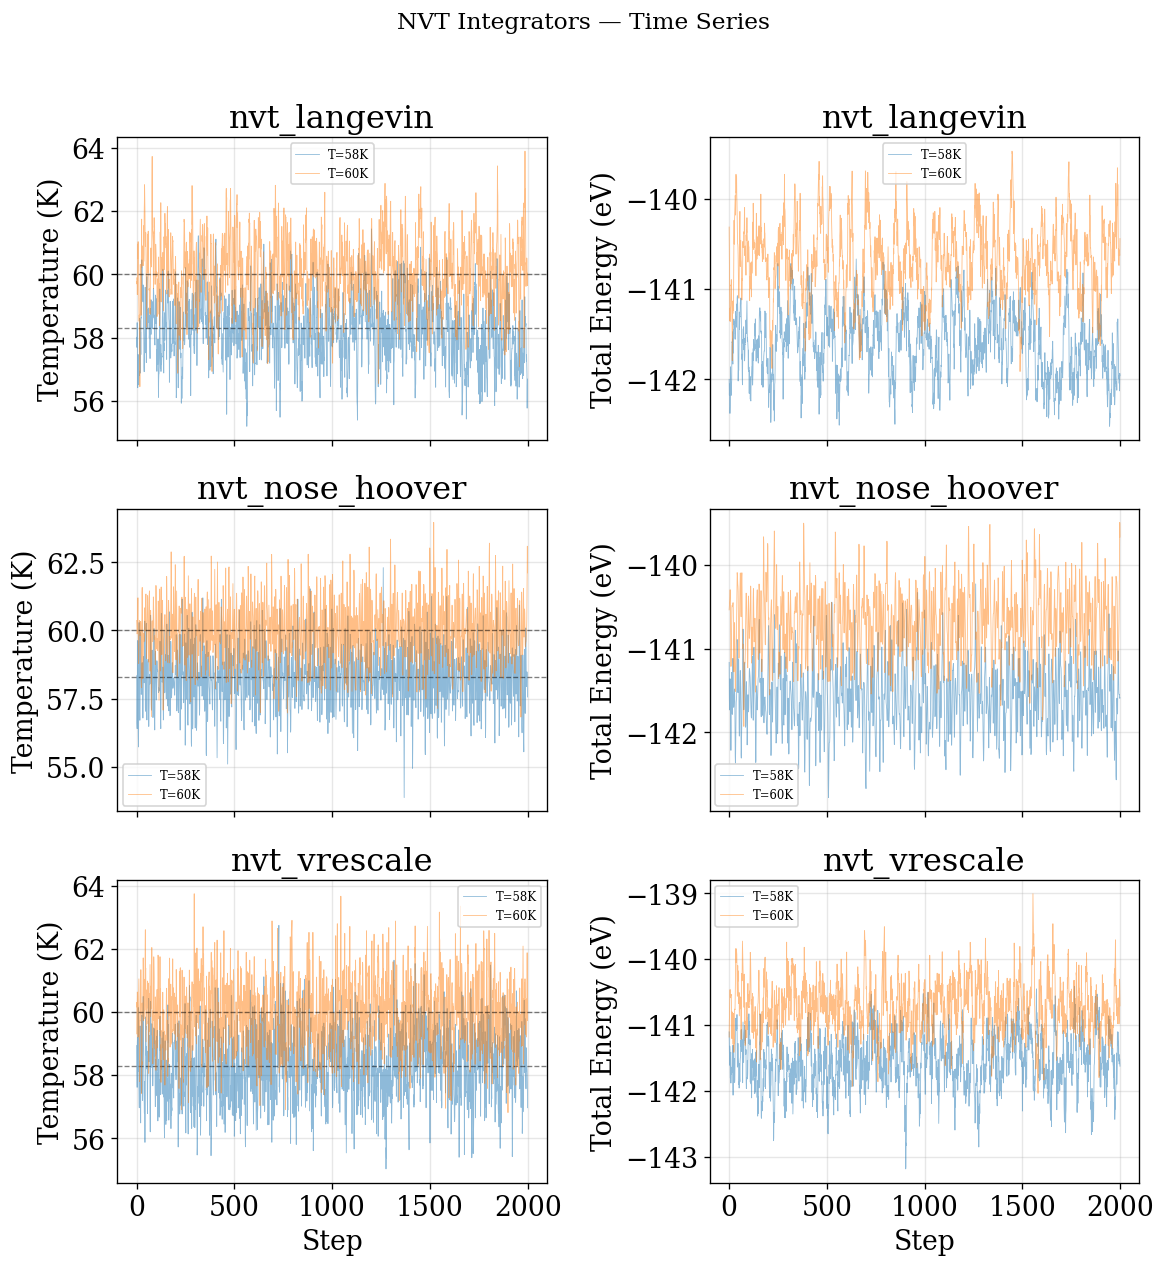

In [46]:
plot_time_series(NVT_INTEGRATORS, "NVT")

### KE Distribution (quick visual check — no decorrelation)

Observed KE histogram vs the theoretical Maxwell-Boltzmann $\text{Gamma}(N_f/2,\, k_BT)$.

**Note:** This plot uses all saved frames directly, without removing equilibration transients
or decorrelating correlated consecutive frames. Because neighboring MD frames are highly
correlated, the effective sample size is much smaller than the frame count. The histogram
*shape* is still meaningful (it shows whether the distribution is correct), but statistics
like $d_\text{mean}$ and $d_\text{width}$ are not correct.

This bias is exactly what the `physical_validation` library removes in the next section
via its internal decorrelation pipeline. The advantage of this quick plot is that it is
trivial to produce and gives an immediate, intuitive sense of the KE distribution.

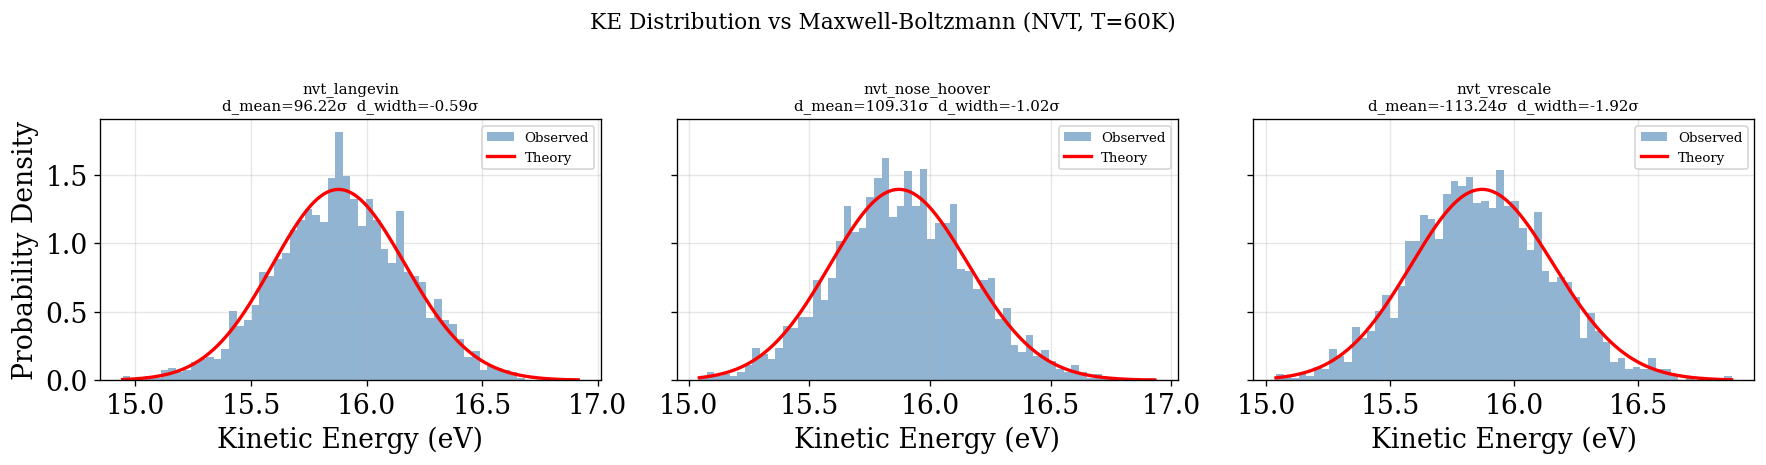

In [47]:
plot_ke_distribution(NVT_INTEGRATORS, "NVT")

#### physical_validation KE check (with decorrelation)

The `physical_validation` library performs the same KE distribution test but first
detects equilibration, decorrelates the time series, and subsamples to obtain
statistically independent frames. This produces properly calibrated $\sigma$-deviations.

**Statistical framework:** The null hypothesis is that the kinetic energy follows
a Gamma distribution (equivalently, for large $N_f$, approximately Gaussian) with
the theoretically predicted mean $\langle E_k \rangle = \tfrac{N_f}{2} k_B T$ and
variance $\text{Var}(E_k) = \tfrac{N_f}{2} (k_B T)^2$. Two independent tests are
performed: one on the mean and one on the distribution width. In each case, the
deviation from the expected value is expressed in units of $\sigma$ (standard deviations
of the estimator). If the corresponding $p$-value is $\geq 0.05$ (roughly $|\sigma| < 2$),
we cannot reject the null hypothesis and conclude that the sampled distribution is
consistent with the correct equilibrium ensemble. The pass/fail threshold used in the
summary table below is more permissive at $|\sigma| < 3$.

After equilibration, decorrelation and tail pruning, 11.95% (239 frames) of original Kinetic energy remain.
p = 0.333037
After equilibration, decorrelation and tail pruning, 62.10% (1242 frames) of original Kinetic energy remain.
p = 0.31748
After equilibration, decorrelation and tail pruning, 39.10% (782 frames) of original Kinetic energy remain.
p = 0.0711083


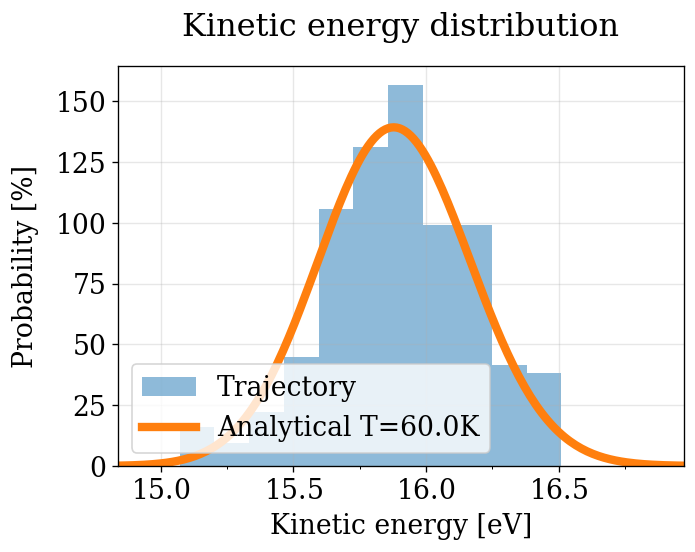

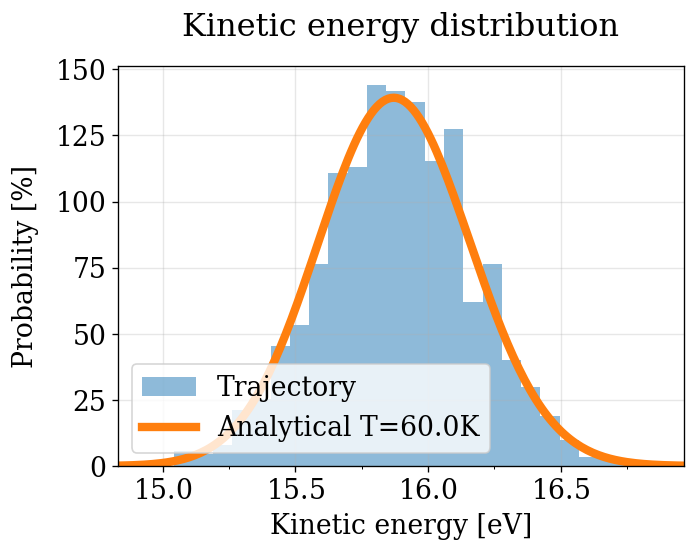

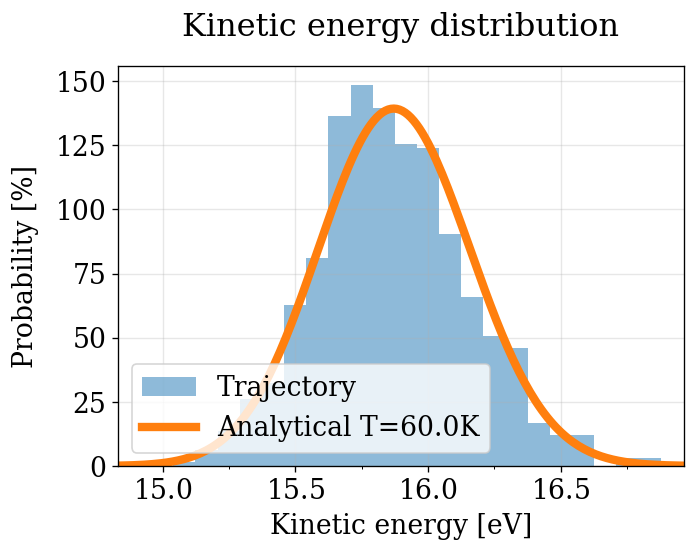

In [48]:
run_pv_ke(NVT_INTEGRATORS, "NVT")

### Ensemble Check (quick visual check — no decorrelation)

Energy histograms at $T_{\text{lo}}=58.3\,$K and $T_{\text{hi}}=60\,$K.
The log-ratio $\ln(P_{\text{lo}}/P_{\text{hi}})$ should be linear with slope $\Delta\beta$.

**Note:** Like the KE plot above, this uses all frames without decorrelation.
Frame-to-frame correlations artificially narrow the energy histograms, which can
bias the fitted slope away from the true $\Delta\beta$. The `physical_validation`
library handles this properly (see next section). This plot is nonetheless valuable
as a quick, easy-to-interpret visual sanity check of the ensemble.

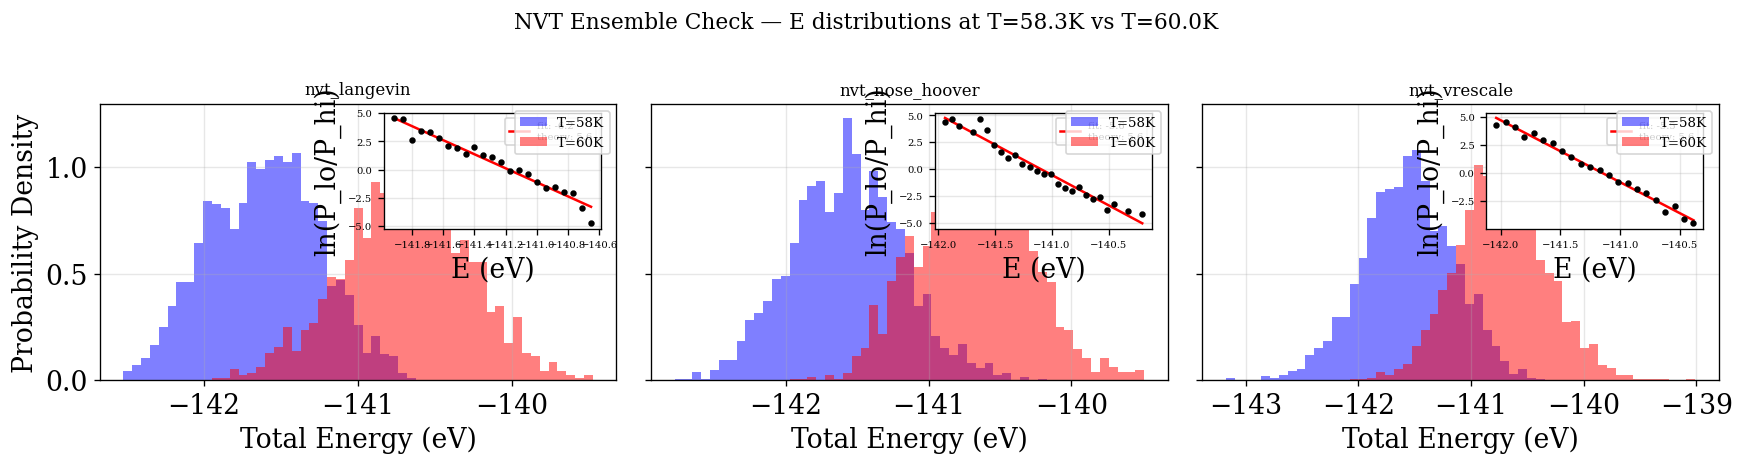

In [49]:
plot_ensemble_check(NVT_INTEGRATORS, "NVT")

#### physical_validation ensemble check (with decorrelation)

The `physical_validation` library performs equilibration detection, decorrelation,
tail pruning, and maximum-likelihood fitting to produce properly calibrated
quantile deviations from the expected $\Delta\beta$.

Note that in order to print the plot, the line is also linearly fitted to the simulations. This leads to a slightly different estimate, which explains the difference between the quantiles printed in the plot and in the terminal. As the maximum likelihood estimate is considered to be more exact, it’s value is reported on the terminal and used as a return value.
Extracted from physical_validation docs, see more: https://physical-validation.readthedocs.io/en/stable/examples/ensemble_check.html

After equilibration, decorrelation and tail pruning, 6.95% (139 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 10.15% (203 frames) of original Trajectory 2 remain.
Overlap is 79.1% of trajectory 1 and 63.1% of trajectory 2.
Rule of thumb estimates that dT = 2.4 would be optimal (currently, dT = 1.7)
Maximum Likelihood Analysis (analytical error)
Free energy
    957.25488 +/- 135.55209
Estimated slope                  |  True slope
    6.102004  +/- 0.864191       |  5.639705 
    (0.53 quantiles from true slope)
Estimated dT                     |  True dT
    1.8    +/- 0.3               |  1.7   
After equilibration, decorrelation and tail pruning, 15.70% (314 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 15.50% (310 frames) of original Trajectory 2 remain.
Overlap is 75.8% of trajectory 1 and 72.6% of trajectory 2.
Rule of thumb estimates that dT = 2.3 would be optimal (currently, dT = 1.7)

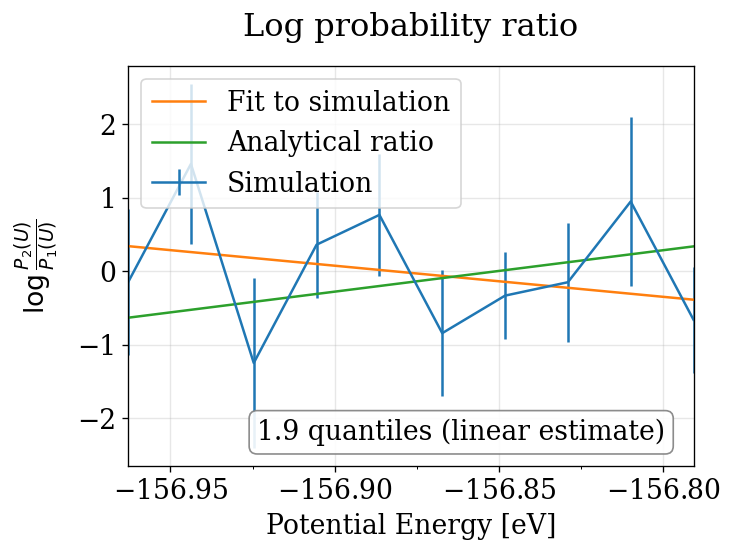

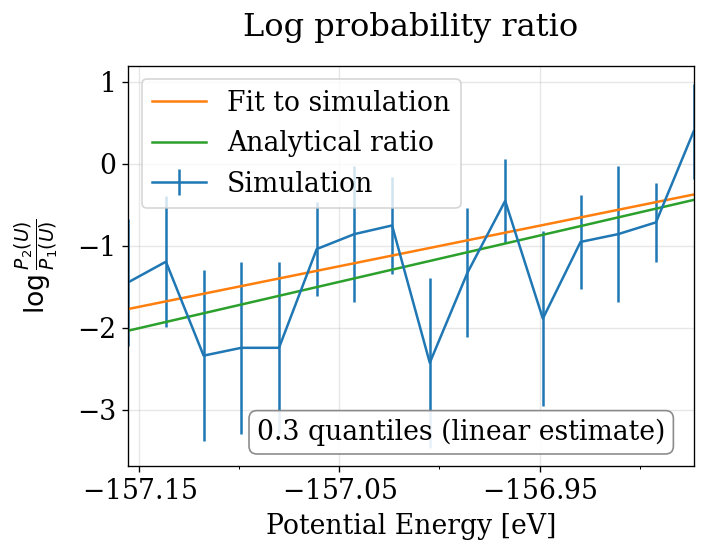

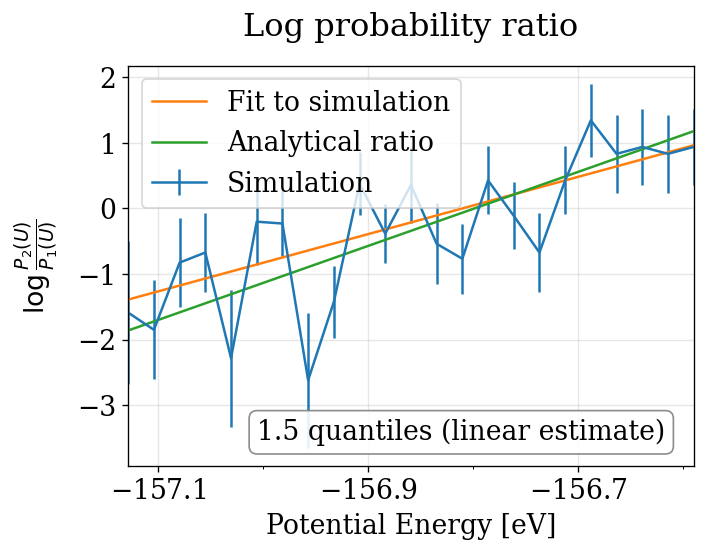

In [50]:
run_pv_ensemble(NVT_INTEGRATORS, "NVT")

---
## NPT Integrators

`npt_langevin` | `npt_nose_hoover` | `npt_isotropic_crescale` | `npt_anisotropic_crescale`

### Time Series

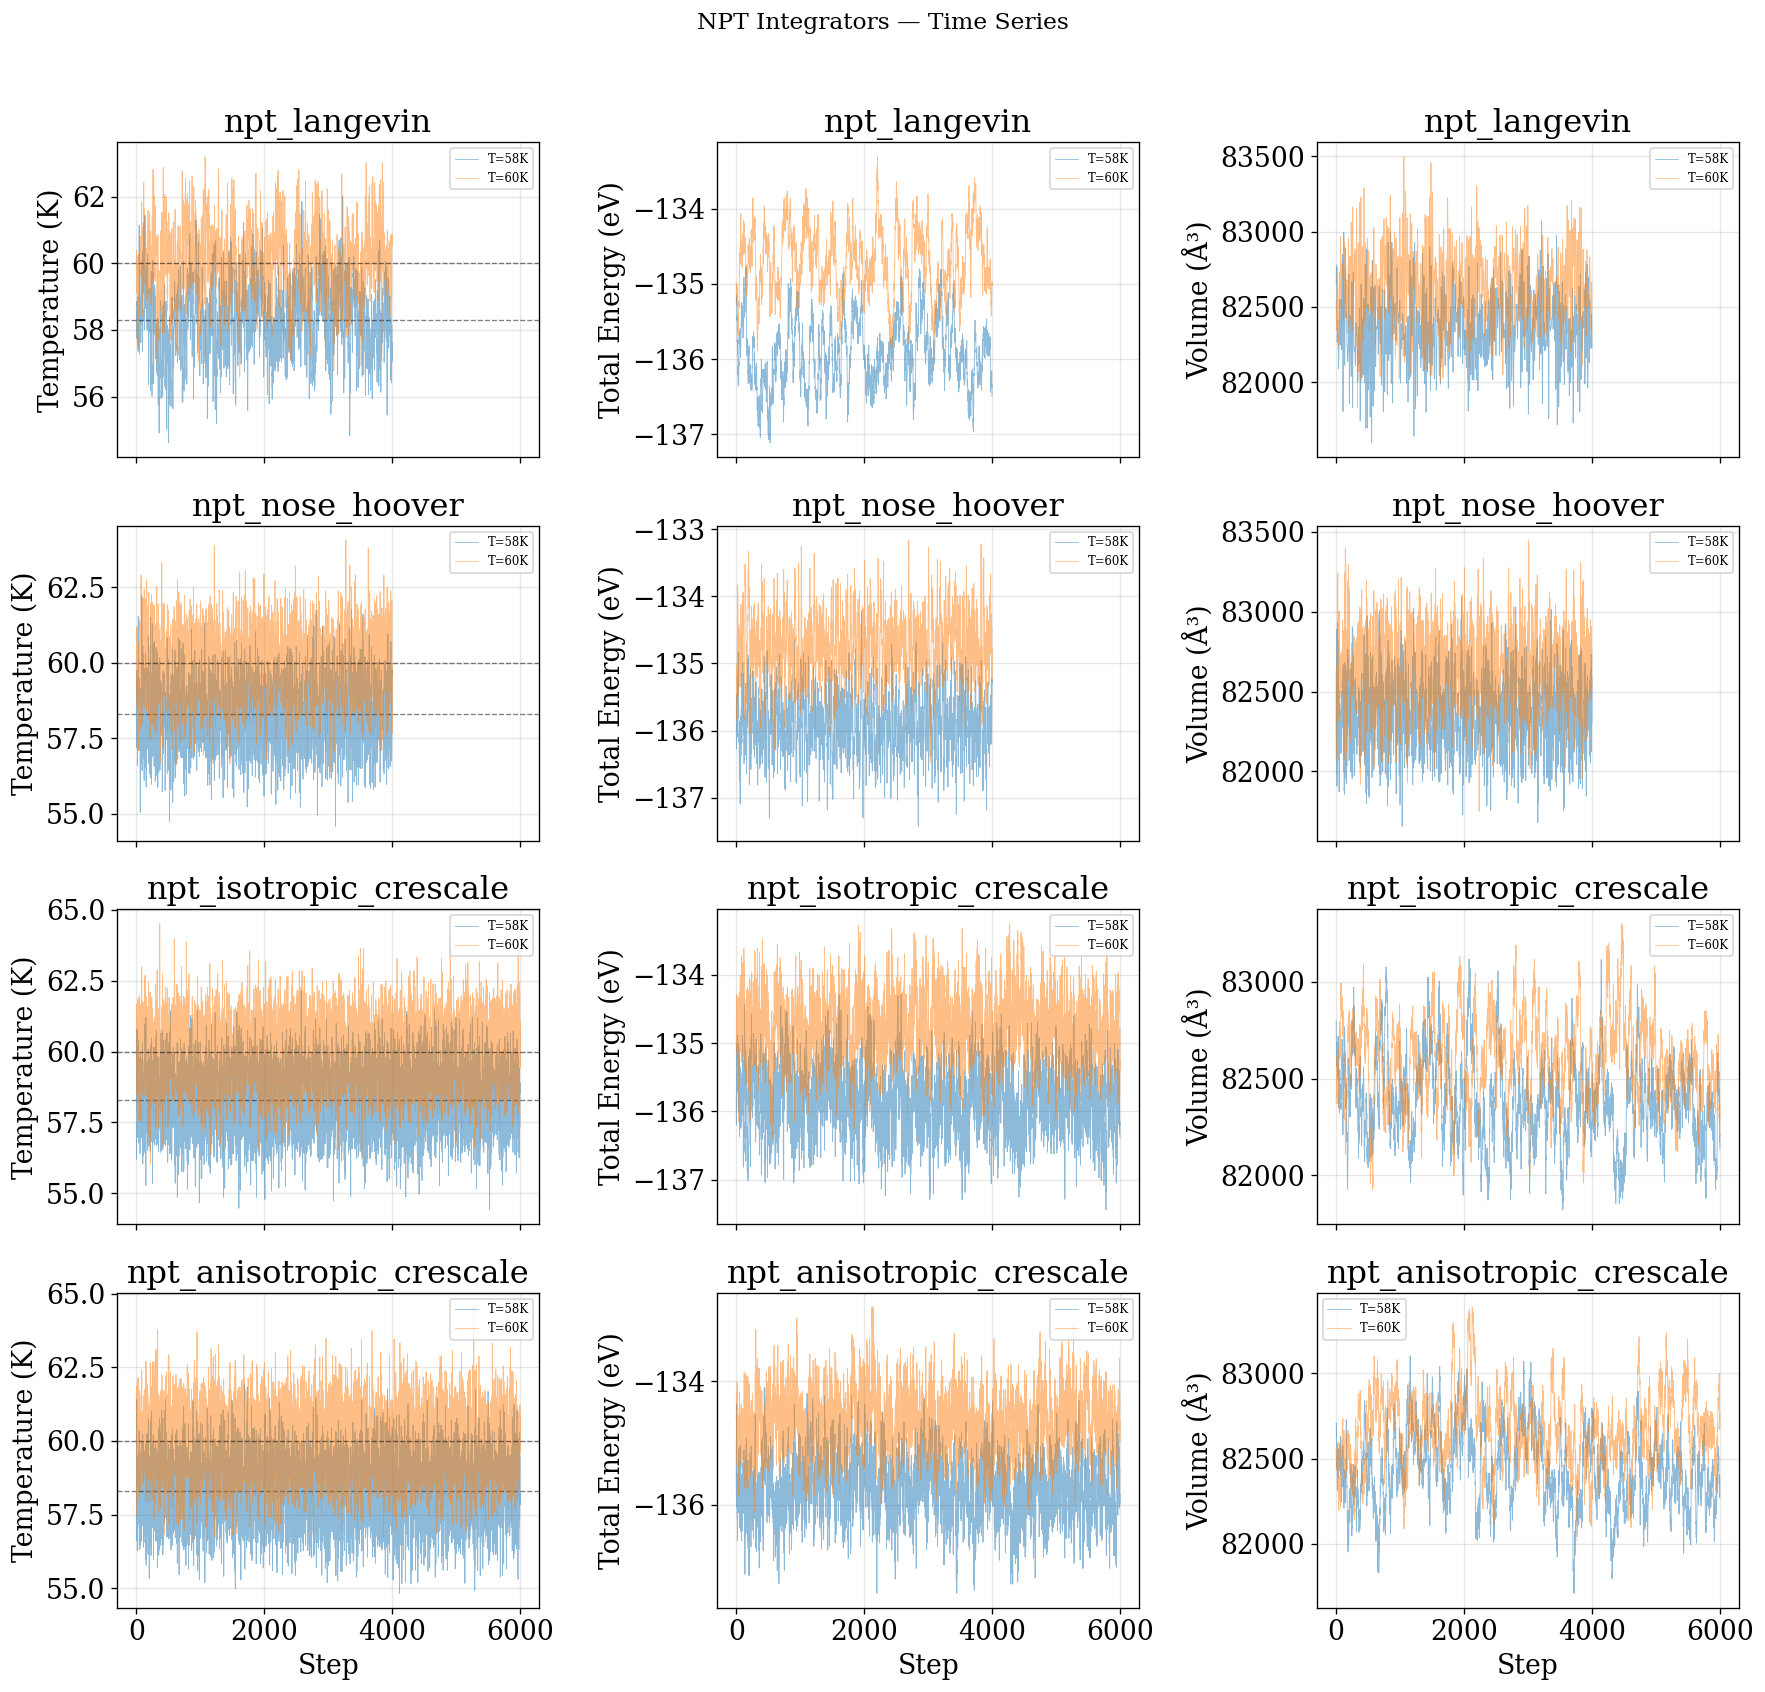

In [51]:
plot_time_series(NPT_INTEGRATORS, "NPT")

### KE Distribution (quick visual check — no decorrelation)

Same as the NVT section: all frames, no decorrelation. See NVT notes on bias.

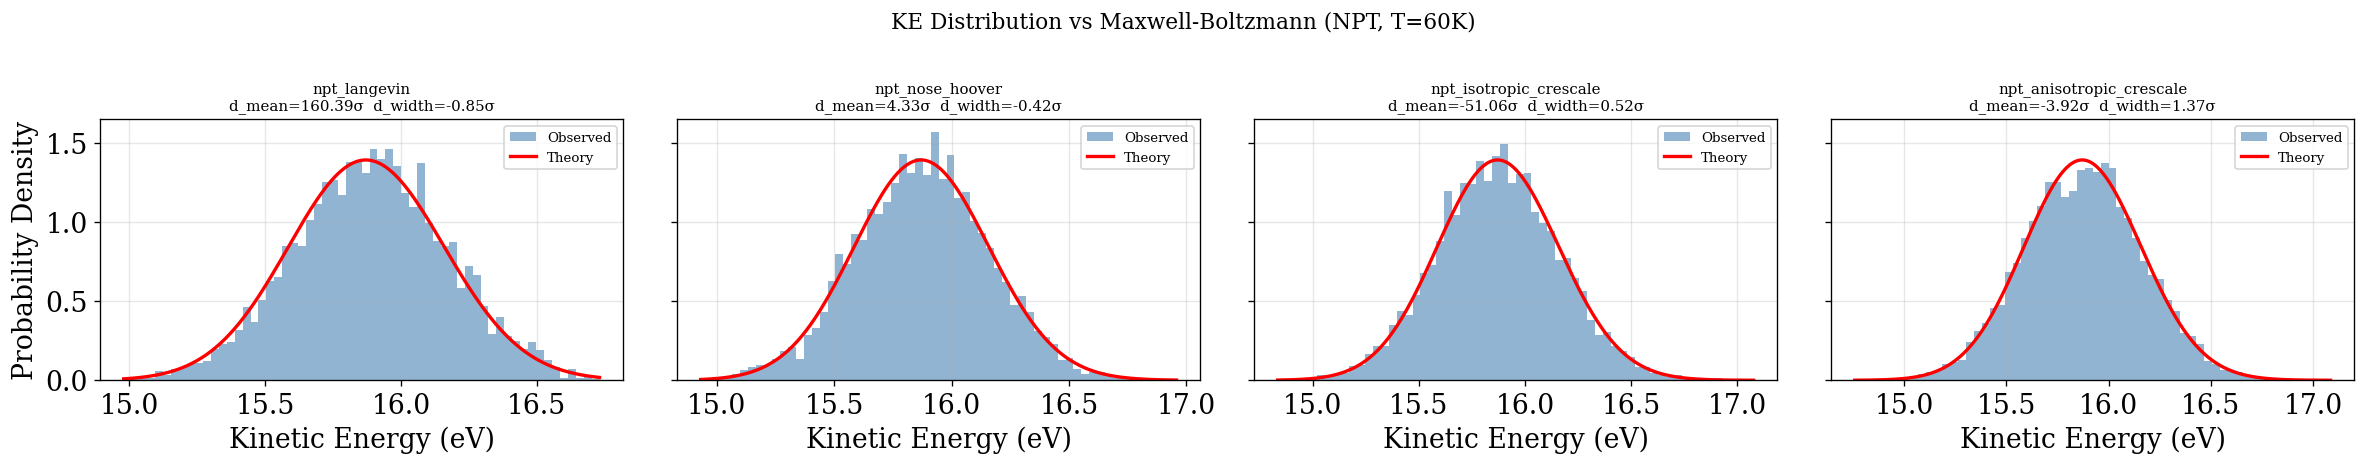

In [52]:
plot_ke_distribution(NPT_INTEGRATORS, "NPT")

#### physical_validation KE check (with decorrelation)

Decorrelated KE distribution test — see NVT section for details on the
statistical framework (null hypothesis, $p$-value interpretation).

After equilibration, decorrelation and tail pruning, 4.47% (179 frames) of original Kinetic energy remain.
p = 0.378334
After equilibration, decorrelation and tail pruning, 57.43% (2297 frames) of original Kinetic energy remain.
p = 0.455113
After equilibration, decorrelation and tail pruning, 97.25% (5835 frames) of original Kinetic energy remain.
p = 0.496138
After equilibration, decorrelation and tail pruning, 94.83% (5690 frames) of original Kinetic energy remain.
p = 0.188362


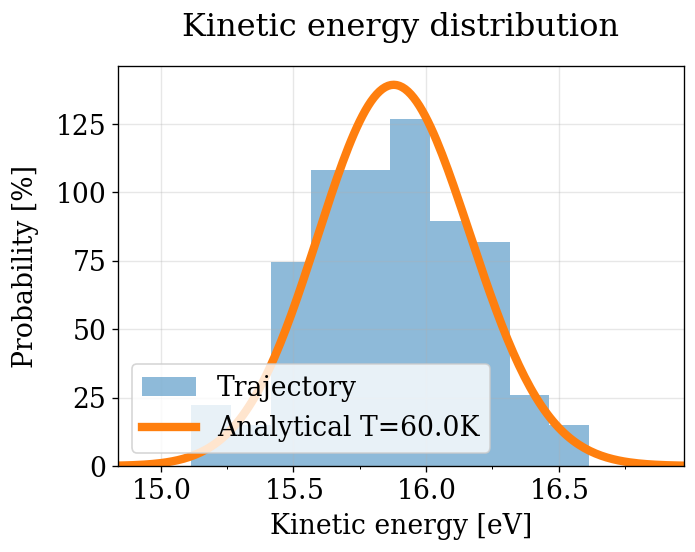

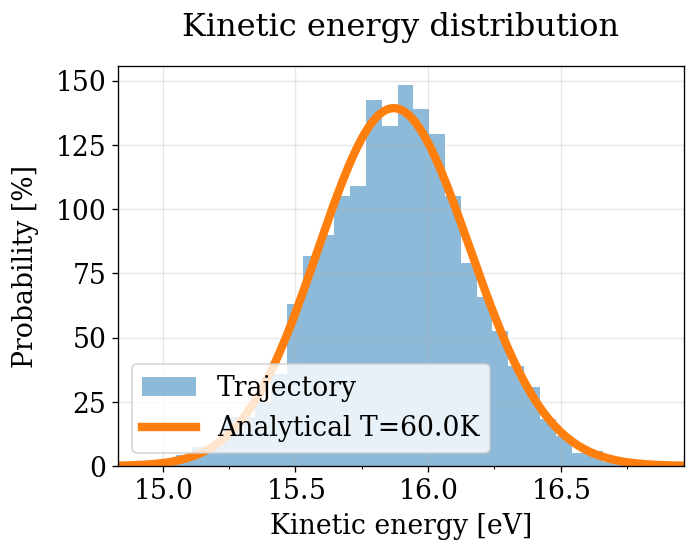

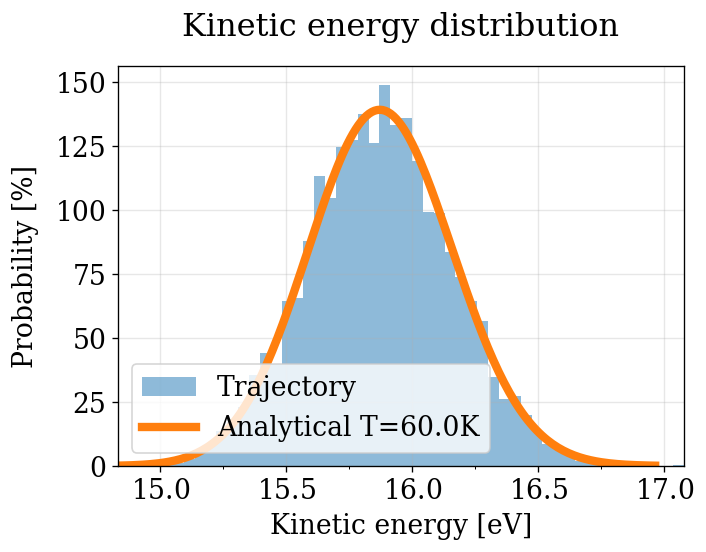

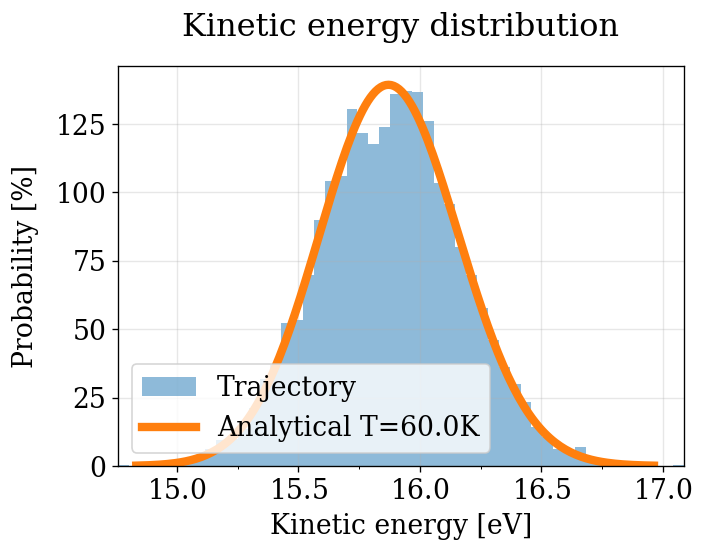

In [53]:
run_pv_ke(NPT_INTEGRATORS, "NPT")

### Ensemble Check — Temperature (quick visual check — no decorrelation)

Same as NVT: all frames, no decorrelation. See NVT notes on bias.

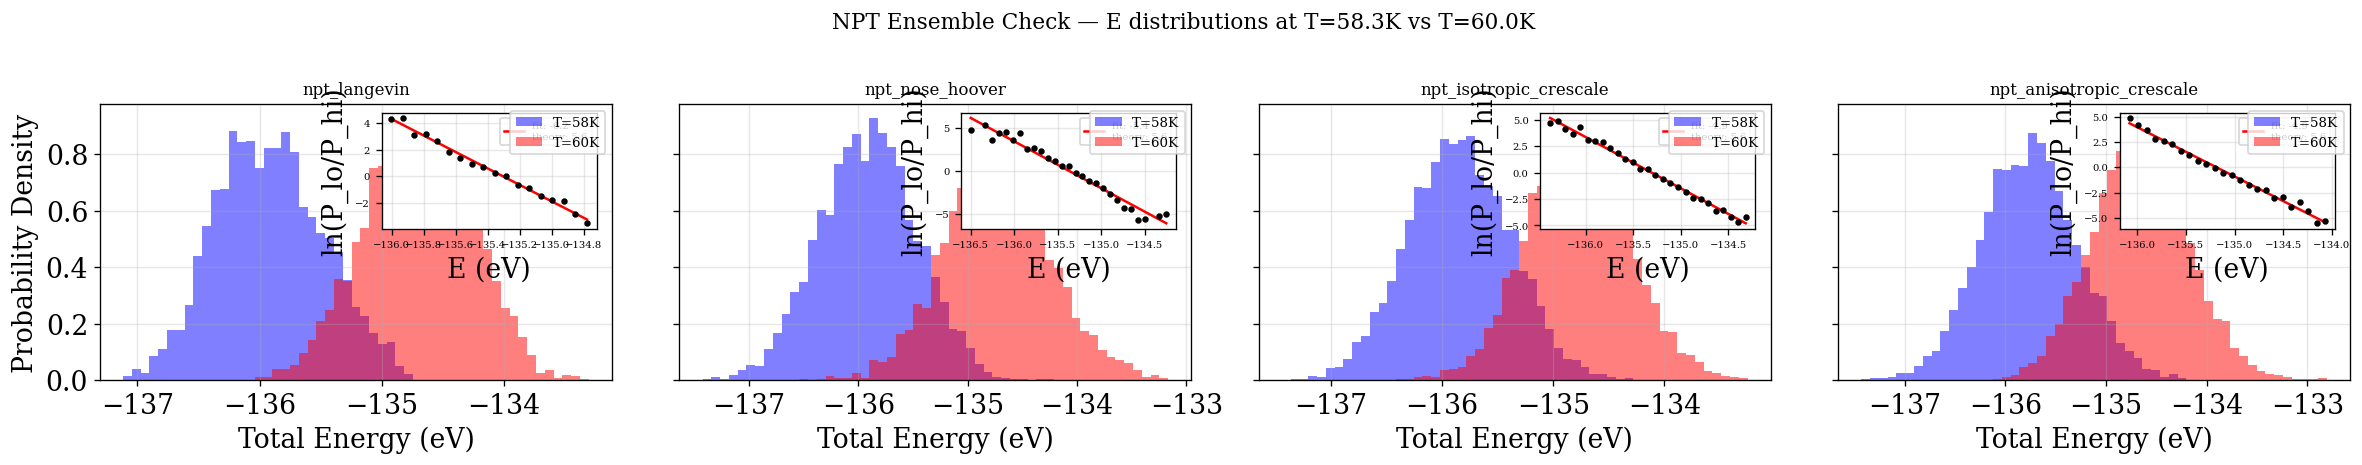

In [54]:
plot_ensemble_check(NPT_INTEGRATORS, "NPT")

#### physical_validation ensemble check (with decorrelation)

Decorrelated ensemble (temperature) check — see NVT section for details.

In [55]:
run_pv_ensemble(NPT_INTEGRATORS, "NPT")

After equilibration, decorrelation and tail pruning, 2.62% (105 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 2.80% (112 frames) of original Trajectory 2 remain.
Overlap is 57.1% of trajectory 1 and 49.1% of trajectory 2.
Rule of thumb estimates that dT = 1.7 would be optimal (currently, dT = 1.7)
Maximum Likelihood Analysis (analytical error)
Free energy
    654.96704 +/- 154.57652
Estimated slope                  |  True slope
    4.338844  +/- 1.023920       |  5.639705 
    (1.27 quantiles from true slope)
Estimated dT                     |  True dT
    1.3    +/- 0.3               |  1.7   
After equilibration, decorrelation and tail pruning, 9.12% (365 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 8.77% (351 frames) of original Trajectory 2 remain.
Overlap is 84.1% of trajectory 1 and 74.1% of trajectory 2.
Rule of thumb estimates that dT = 1.7 would be optimal (currently, dT = 1.7)
Ma

### Ensemble Check — Pressure (quick visual check — no decorrelation)

Volume distributions at different pressures (same $T$). As with all "quick" plots
in this notebook, all frames are used without decorrelation. The `physical_validation`
pressure ensemble check in the next section properly decorrelates before fitting.

In [56]:
P_BAR_CONVERSION = float(MetalUnits.pressure)

# Discover pressure-sweep files
pressure_data = {}
for f in sorted(DATA_DIR.glob("npt*_P*bar.npz")):
    parts = f.stem.rsplit("_P", 1)
    if len(parts) != 2:
        continue
    int_name = parts[0].rsplit("_T", 1)[0]
    p_bar = float(parts[1].replace("bar", ""))
    pressure_data.setdefault(int_name, []).append((p_bar, f.stem))
for f in sorted(DATA_DIR.glob("npt*_T60.0K.npz")):
    if "_P" not in f.stem:
        int_name = f.stem.rsplit("_T", 1)[0]
        pressure_data.setdefault(int_name, []).append((0.0, f.stem))
for entries in pressure_data.values():
    entries.sort(key=lambda x: x[0])

integrators_with_pressure = [n for n in NPT_INTEGRATORS if n in pressure_data]

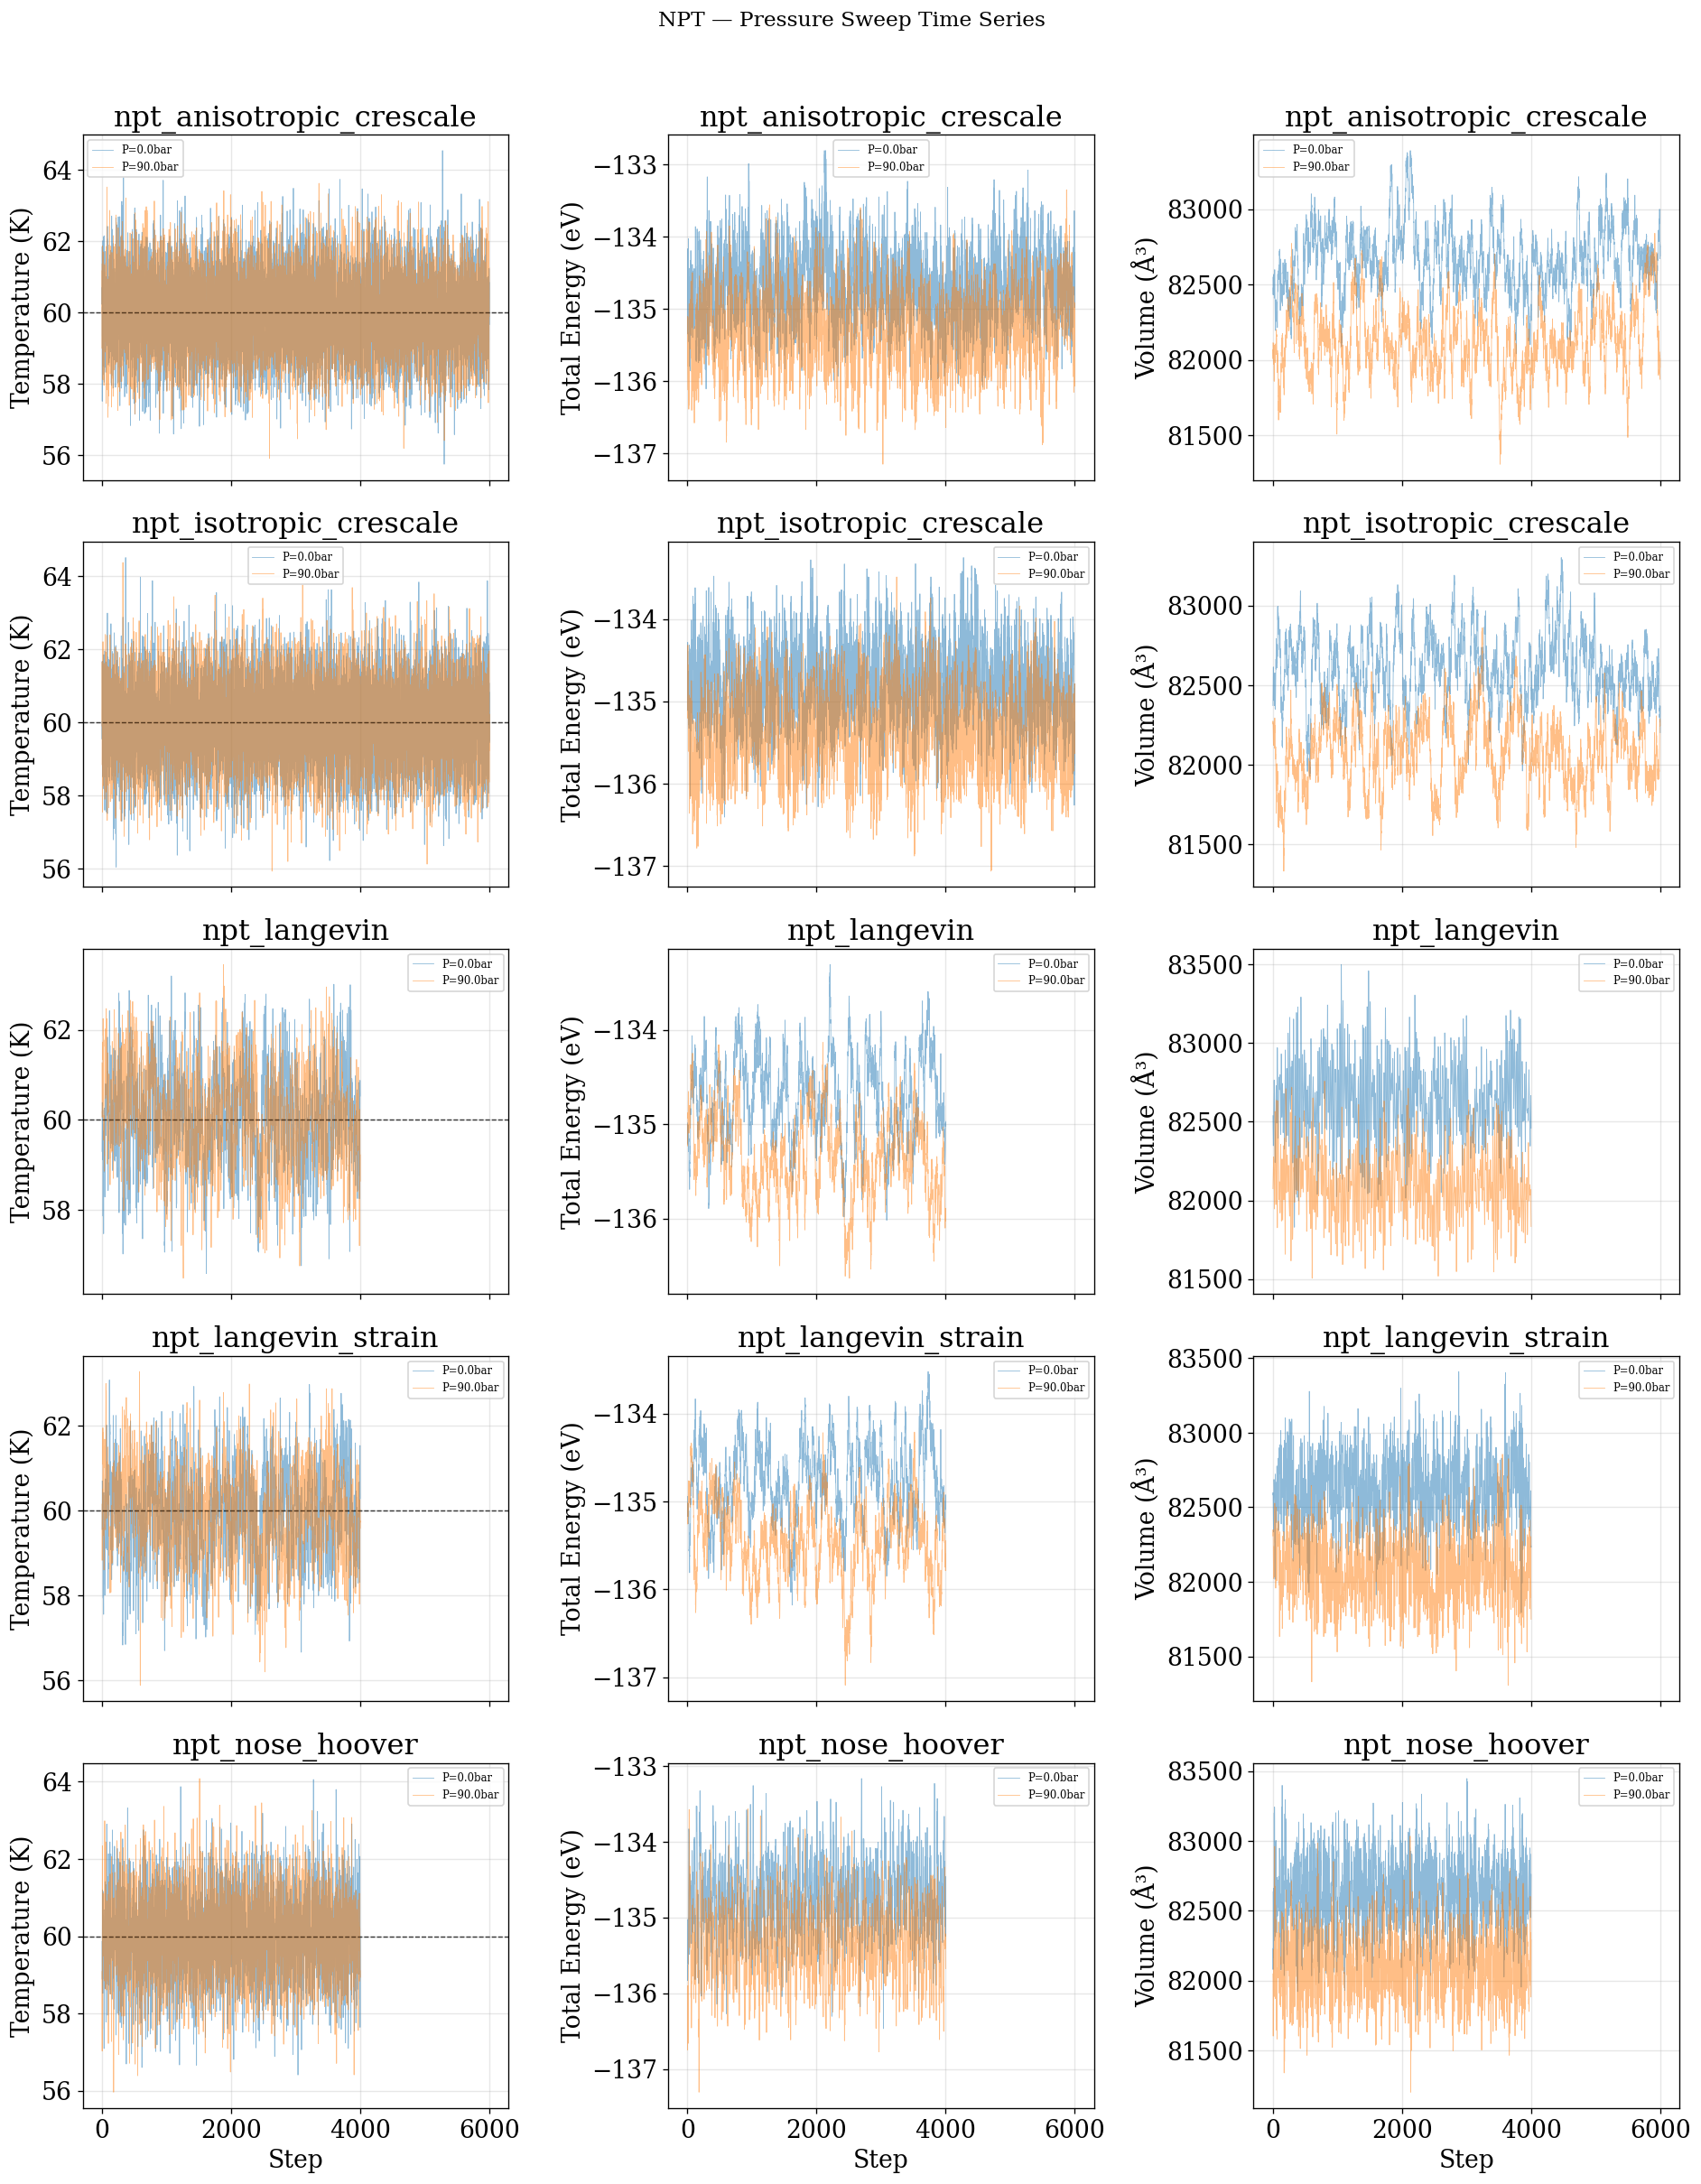

In [57]:
# Pressure-sweep time series
fig, axes = plt.subplots(
    len(pressure_data),
    3,
    figsize=(16, 4 * len(pressure_data)),
    squeeze=False,
    sharex=True,
)
fig.suptitle("NPT — Pressure Sweep Time Series", fontsize=14, y=1.01)
for row, (name, entries) in enumerate(pressure_data.items()):
    for p_bar, fn in entries:
        try:
            d = load(fn)
        except FileNotFoundError:
            continue
        steps = np.arange(len(d["temperature"]))
        T = float(d["target_temperature"])
        tag = f"P={p_bar:.1f}bar"
        axes[row, 0].plot(steps, d["temperature"], alpha=0.5, lw=0.5, label=tag)
        axes[row, 0].axhline(T, color="k", ls="--", lw=0.8, alpha=0.5)
        axes[row, 0].set(ylabel="Temperature (K)", title=name)
        axes[row, 0].legend(fontsize=7)
        axes[row, 1].plot(steps, d["total_energy"], alpha=0.5, lw=0.5, label=tag)
        axes[row, 1].set(ylabel="Total Energy (eV)", title=name)
        axes[row, 1].legend(fontsize=7)
        axes[row, 2].plot(steps, d["volumes"], alpha=0.5, lw=0.5, label=tag)
        axes[row, 2].set(ylabel="Volume (\u00c5\u00b3)", title=name)
        axes[row, 2].legend(fontsize=7)
for j in range(3):
    axes[-1, j].set_xlabel("Step")
fig.tight_layout()
plt.show()

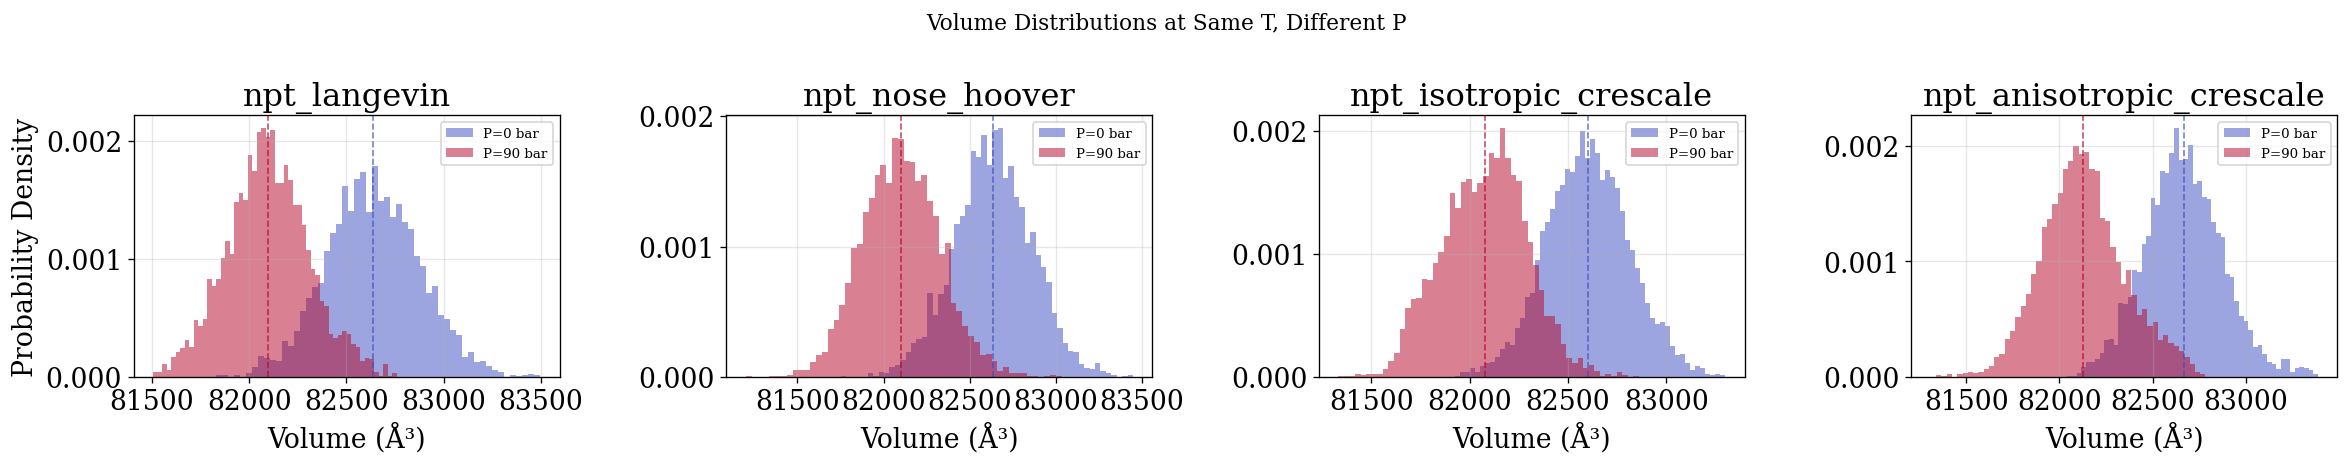

In [58]:
# Volume distributions at different pressures
if integrators_with_pressure:
    fig, axes = plt.subplots(
        1,
        len(integrators_with_pressure),
        figsize=(5 * len(integrators_with_pressure), 4),
        squeeze=False,
    )
    axes = axes[0]
    fig.suptitle("Volume Distributions at Same T, Different P", fontsize=13)
    for ax, name in zip(axes, integrators_with_pressure):
        colors = plt.cm.coolwarm(np.linspace(0, 1, len(pressure_data[name])))
        for (p_bar, fn), c in zip(pressure_data[name], colors):
            v = load(fn)["volumes"]
            ax.hist(
                v, bins=54, density=True, alpha=0.5, color=c, label=f"P={p_bar:.0f} bar"
            )
            ax.axvline(v.mean(), color=c, ls="--", lw=1, alpha=0.7)
        ax.set(title=name, xlabel="Volume (\u00c5\u00b3)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Probability Density")
    fig.tight_layout()
    plt.show()

#### physical_validation pressure ensemble check (with decorrelation)

The `physical_validation` library auto-detects the NPT pressure case and performs
a 1D volume-based maximum-likelihood check with proper decorrelation.

After equilibration, decorrelation and tail pruning, 11.82% (473 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 11.35% (454 frames) of original Trajectory 2 remain.
Overlap is 61.3% of trajectory 1 and 66.1% of trajectory 2.
Rule of thumb estimates that dP = 73.9 would be optimal (currently, dP = 90.0)
Maximum Likelihood Analysis (analytical error)
Free energy
    808.38621 +/- 76.94602
Estimated slope                  |  True slope
    -0.009816 +/- 0.000934       |  -0.010864
    (1.12 quantiles from true slope)
Estimated dP                     |  True estimated dP
    81.3   +/- 7.7               |  90.0  
  npt_langevin P=[0.0,90.0] bar: quantiles = ['1.122']
After equilibration, decorrelation and tail pruning, 36.65% (1466 frames) of original Trajectory 1 remain.
After equilibration, decorrelation and tail pruning, 37.72% (1509 frames) of original Trajectory 2 remain.
Overlap is 78.0% of trajectory 1 and 70.8% of trajectory 2.
Rule of

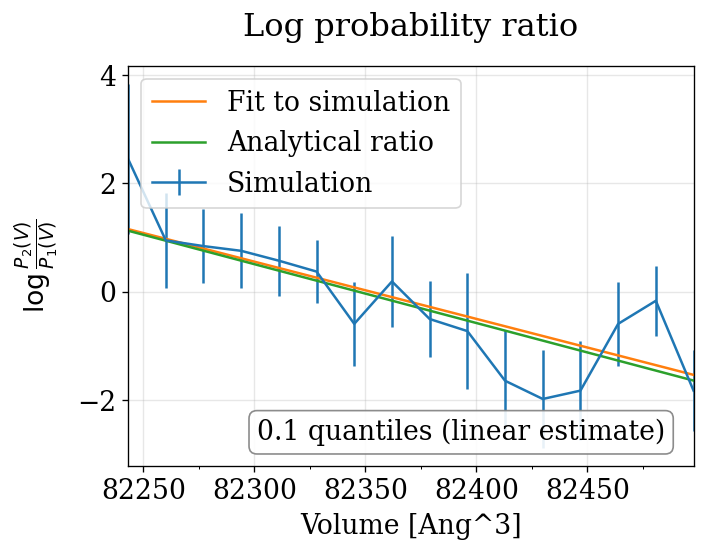

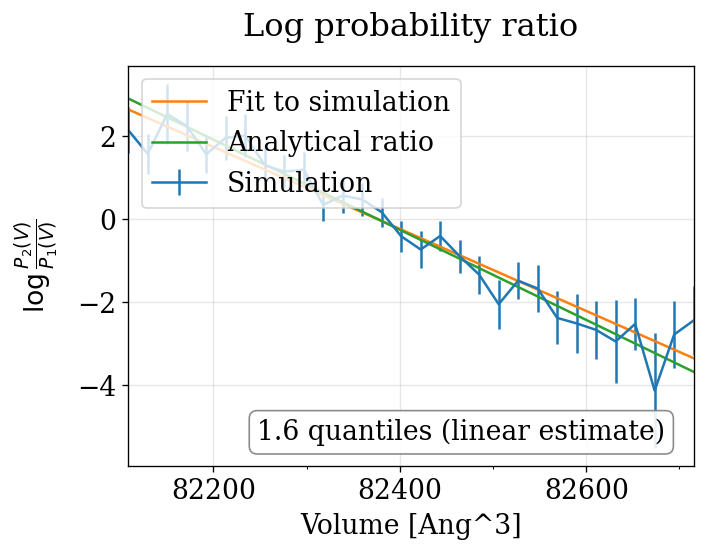

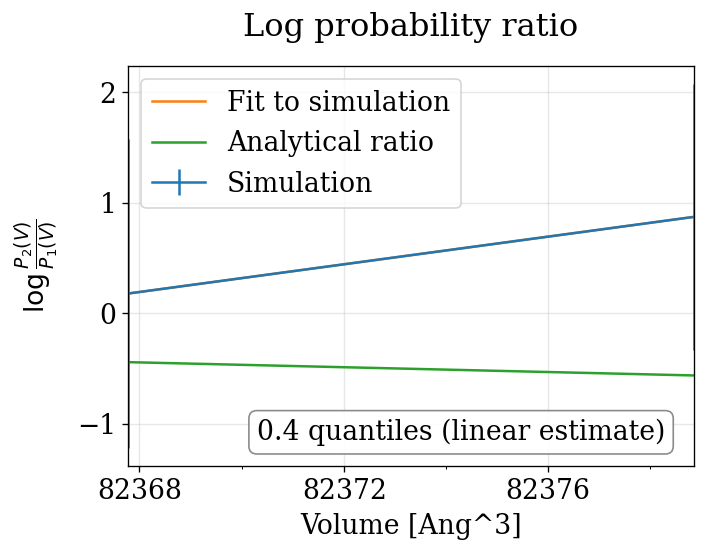

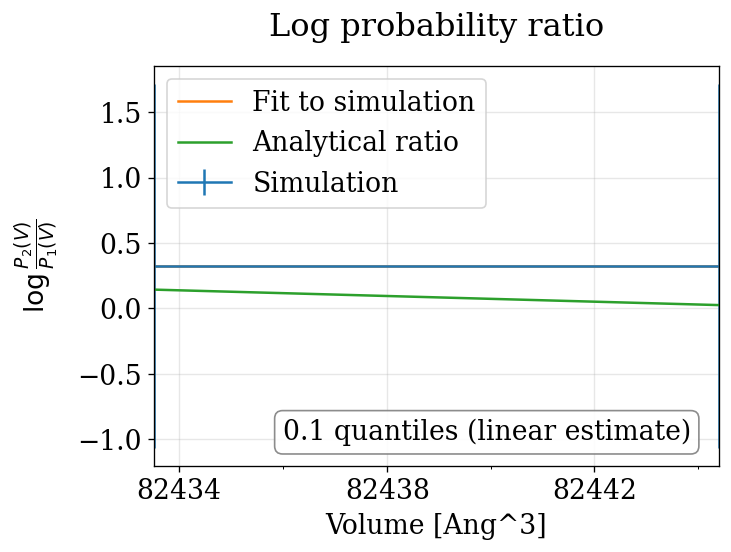

In [59]:
for name in integrators_with_pressure:
    entries = pressure_data[name]
    if len(entries) < 2:
        continue
    p_lo_bar, fn_lo = entries[0]
    p_hi_bar, fn_hi = entries[-1]
    d_lo, d_hi = load(fn_lo), load(fn_hi)
    temp = float(d_lo["target_temperature"])
    sd_lo = build_sim_data(d_lo, temp, ensemble="NPT", pressure=p_lo_bar, integrator=name)
    sd_hi = build_sim_data(d_hi, temp, ensemble="NPT", pressure=p_hi_bar, integrator=name)
    try:
        q = physical_validation.ensemble.check(
            sd_lo, sd_hi, total_energy=False, screen=True, verbosity=1
        )
        print(
            f"  {name} P=[{p_lo_bar},{p_hi_bar}] bar: quantiles = {[f'{x:.3f}' for x in q]}"
        )
    except Exception as e:
        print(f"  {name}: {e}")
plt.show()

---
## Summary

Programmatic pass/fail for all integrators ($|\sigma| < 3$ = pass).

In [60]:
results = []
for name in NVT_INTEGRATORS + NPT_INTEGRATORS:
    ens = "NPT" if name.startswith("npt") else "NVT"
    # KE
    ke_s = "no data"
    try:
        d = load(f"{name}_T60.0K")
        sd = build_sim_data(d, 60.0, ensemble=ens, integrator=name)
        dm, dw = physical_validation.kinetic_energy.distribution(
            sd, strict=False, verbosity=0
        )
        ok = abs(dm) < THRESHOLD and abs(dw) < THRESHOLD
        ke_s = f"{'PASS' if ok else 'FAIL'} (\u03bc={dm:.2f}\u03c3, w={dw:.2f}\u03c3)"
    except Exception as e:
        ke_s = f"ERROR: {e}"
    # Ensemble (T)
    ens_s = "no data"
    try:
        sd_lo = build_sim_data(
            load(f"{name}_T58.3K"), 58.3, ensemble=ens, integrator=name
        )
        sd_hi = build_sim_data(
            load(f"{name}_T60.0K"), 60.0, ensemble=ens, integrator=name
        )
        q = physical_validation.ensemble.check(
            sd_lo, sd_hi, total_energy=False, data_is_uncorrelated=False, verbosity=0
        )
        mq = max(abs(x) for x in q)
        ok = mq < THRESHOLD
        ens_s = f"{'PASS' if ok else 'FAIL'} (max |q|={mq:.2f}\u03c3)"
    except Exception as e:
        ens_s = f"ERROR: {e}"
    # Ensemble (P) — NPT only
    pr_s = "N/A"
    if name.startswith("npt") and name in pressure_data:
        entries = pressure_data[name]
        if len(entries) >= 2:
            try:
                d_lo, d_hi = load(entries[0][1]), load(entries[-1][1])
                t = float(d_lo["target_temperature"])
                sd_lo = build_sim_data(
                    d_lo, t, ensemble="NPT", pressure=entries[0][0], integrator=name
                )
                sd_hi = build_sim_data(
                    d_hi, t, ensemble="NPT", pressure=entries[-1][0], integrator=name
                )
                q = physical_validation.ensemble.check(
                    sd_lo,
                    sd_hi,
                    total_energy=False,
                    data_is_uncorrelated=False,
                    verbosity=0,
                )
                mq = max(abs(x) for x in q)
                ok = mq < THRESHOLD
                pr_s = f"{'PASS' if ok else 'FAIL'} (max |q|={mq:.2f}\u03c3)"
            except Exception as e:
                pr_s = f"ERROR: {e}"
    results.append((name, ke_s, ens_s, pr_s))

print(
    f"{'Integrator':<30} {'KE Distribution':<40} {'Ensemble (T)':<35} {'Ensemble (P)':<35}"
)
print("-" * 140)
for r in results:
    print(f"{r[0]:<30} {r[1]:<40} {r[2]:<35} {r[3]:<35}")

Integrator                     KE Distribution                          Ensemble (T)                        Ensemble (P)                       
--------------------------------------------------------------------------------------------------------------------------------------------
nvt_langevin                   PASS (μ=0.96σ, w=0.55σ)                  PASS (max |q|=0.53σ)                N/A                                
nvt_nose_hoover                PASS (μ=1.34σ, w=0.61σ)                  PASS (max |q|=0.47σ)                N/A                                
nvt_vrescale                   PASS (μ=1.09σ, w=0.21σ)                  PASS (max |q|=1.56σ)                N/A                                
npt_langevin                   PASS (μ=0.51σ, w=1.22σ)                  PASS (max |q|=1.27σ)                PASS (max |q|=1.12σ)               
npt_nose_hoover                PASS (μ=0.22σ, w=0.04σ)                  PASS (max |q|=0.68σ)                PASS (max |q|=1.14σ)           